# Занятие 34. Практика: переобучение и validation curve (~90 мин)

**Только для преподавателя. Не выдавать студентам.**

Эталон практики. Ячейку **«Дано»** не меняйте.

Главная модель — **LinearRegression + PolynomialFeatures** (теория — занятие 33, `overfitting_validation_theory.ipynb`).

Построим validation curve по степени полинома, learning curve и k-fold CV на синтетических данных (как в п. 6–10 теории).

Термины train/validation/test и три состояния модели — пп. 1–2 теории. Здесь только практика.

---
## Дано: синтетическая регрессия

Объект — одна точка на оси X. Цель — предсказать `y ≈ x²` с шумом. Это тот же пример, что в теории: видно недообучение, хорошее обобщение и переобучение.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
X = np.linspace(-3, 3, 180).reshape(-1, 1)
y = X[:, 0] ** 2 + rng.normal(0, 1.5, len(X))
print('Объектов:', len(X))

Объектов: 180


---
## Задание 0. Импорты и split (~8 мин)

Подключите `train_test_split`, `PolynomialFeatures`, `LinearRegression`, `mean_squared_error`, `learning_curve`, `cross_validate`, `KFold`.

Константы: `RANDOM_STATE = 42`, разбиение **70% train / 30% validation** (как в теории, п. 6).

**Критерий:** получены `X_train`, `X_val`, `y_train`, `y_val`.

In [2]:
from sklearn.model_selection import train_test_split, learning_curve, cross_validate, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)
print('train / val:', len(X_train), len(X_val))

train / val: 126 54


---
## Задание 1. Validation curve (~20 мин)

По мотивам п. 8. Для степеней полинома **1–15**:

1. `PolynomialFeatures` → `fit` только на train, `transform` на train и val.
2. Обучите `LinearRegression`, посчитайте **MSE** на train и validation.
3. Постройте график «степень → MSE».

**Критерий:** виден U-образный (или похожий) validation MSE; train MSE падает монотонно.

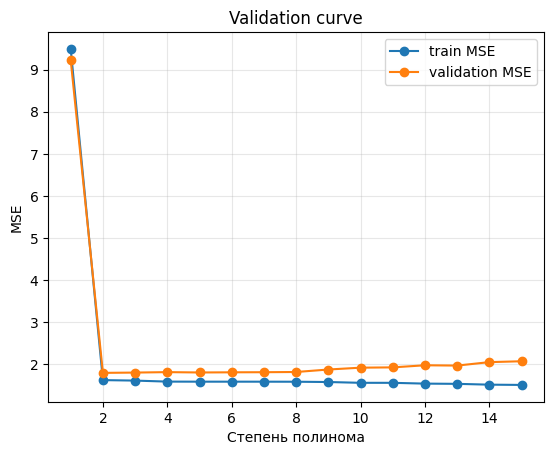

Лучшая степень по validation: 2


In [3]:
degrees = range(1, 16)
train_scores, val_scores = [], []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    Xtr = poly.fit_transform(X_train)
    Xva = poly.transform(X_val)
    m = LinearRegression().fit(Xtr, y_train)
    train_scores.append(mean_squared_error(y_train, m.predict(Xtr)))
    val_scores.append(mean_squared_error(y_val, m.predict(Xva)))

plt.plot(degrees, train_scores, marker='o', label='train MSE')
plt.plot(degrees, val_scores, marker='o', label='validation MSE')
plt.xlabel('Степень полинома')
plt.ylabel('MSE')
plt.title('Validation curve')
plt.grid(alpha=0.3)
plt.legend()
plt.show()
best_degree = degrees[int(np.argmin(val_scores))]
print('Лучшая степень по validation:', best_degree)

---
## Задание 2. Диагноз переобучения (~10 мин)

Выберите степень с **минимальным validation MSE** (`best_degree`) и степень **14** (или 15).

Сравните train vs validation MSE. В markdown ниже: где недообучение, где переобучение? (п. 2)

**Критерий:** для большой степени train MSE << validation MSE.

In [4]:
for d in [best_degree, 14]:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xtr = poly.fit_transform(X_train)
    Xva = poly.transform(X_val)
    m = LinearRegression().fit(Xtr, y_train)
    print(
        f'degree={d}: train MSE={mean_squared_error(y_train, m.predict(Xtr)):.2f}, '
        f'val MSE={mean_squared_error(y_val, m.predict(Xva)):.2f}'
    )

degree=2: train MSE=1.62, val MSE=1.80
degree=14: train MSE=1.52, val MSE=2.05


---
## Задание 3. Learning curve (~15 мин)

По мотивам п. 9. Для `best_degree` постройте **learning curve** (`learning_curve`, 5-fold CV, `neg_mean_squared_error`).

Важно: в sklearn метрика `neg_mean_squared_error` возвращается со знаком минус, потому что при подборе модели большее значение считается лучше. Чтобы получить обычный MSE, умножьте это значение на `-1`.

**Критерий:** график train vs CV MSE от размера train.


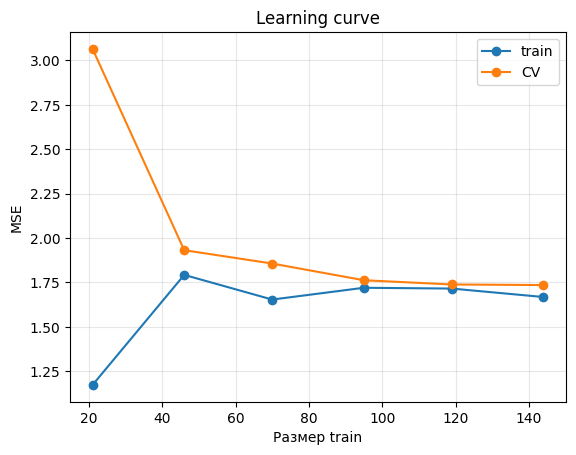

In [5]:
poly_best = PolynomialFeatures(degree=best_degree, include_bias=False)
X_poly = poly_best.fit_transform(X)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
sizes, tr, va = learning_curve(
    LinearRegression(), X_poly, y, cv=cv,
    train_sizes=np.linspace(0.15, 1.0, 6),
    scoring='neg_mean_squared_error', shuffle=True, random_state=RANDOM_STATE,
)
plt.plot(sizes, -tr.mean(axis=1), marker='o', label='train')
plt.plot(sizes, -va.mean(axis=1), marker='o', label='CV')
plt.xlabel('Размер train')
plt.ylabel('MSE')
plt.title('Learning curve')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

---
## Задание 4. K-fold CV (~12 мин)

По мотивам п. 10. `cross_validate` с 5-fold для модели с `best_degree`. Выведите среднюю validation MSE и std.

В выводе `cross_validate` колонка `test_score` означает значение метрики на fold-validation, а не финальный test из train/validation/test.

**Критерий:** напечатана колонка `test_score`, переведённая в положительный MSE, а также среднее и стандартное отклонение.


In [6]:
result = cross_validate(
    LinearRegression(), X_poly, y, cv=cv,
    scoring='neg_mean_squared_error', return_train_score=True,
)
print('CV MSE scores:', (-result['test_score']).round(3))
print('Средняя validation MSE:', round(-result['test_score'].mean(), 3))

CV MSE scores: [2.227 1.38  2.42  1.301 1.348]
Средняя validation MSE: 1.735


---
## Задание 5. Параметры vs гиперпараметры (~8 мин)

В markdown: что в этом эксперименте **параметр** модели, а что **гиперпараметр**? (п. 5)

**Критерий:** степень полинома — гиперпараметр; коэффициенты регрессии — параметры.

---
## Задание 6. Утечка в preprocessing (~10 мин)

По мотивам п. 12. Объясните в markdown, почему нельзя делать `StandardScaler.fit_transform` или `SimpleImputer.fit_transform` на **всей** таблице до split.

Подсказка: такие преобразования запоминают статистики данных — среднее, стандартное отклонение или медиану. Если считать их по всей таблице, validation/test частично влияют на preprocessing.

**Критерий:** объяснено, что статистики preprocessing нужно `fit` только на train, а validation/test обрабатывать через `transform`.


---
## Задание 7. Выбранная модель (~12 мин)

Обучите выбранную модель: `best_degree`, `fit` poly на **train**, оцените MSE на **validation** ещё раз.

Это ещё не финальный test, а проверка выбранной модели на validation.

**Критерий:** validation MSE близка к минимуму из задания 1.


In [7]:
poly_final = PolynomialFeatures(degree=best_degree, include_bias=False)
Xtr = poly_final.fit_transform(X_train)
Xva = poly_final.transform(X_val)
final = LinearRegression().fit(Xtr, y_train)
print('Final validation MSE:', round(mean_squared_error(y_val, final.predict(Xva)), 3))

Final validation MSE: 1.796


---
## Задание 8. Итог (~5 мин)

В markdown: 3 вывода — validation curve, learning curve, честный fit poly только на train.

**Критерий:** три коротких пункта.